Importing Requisite Libraries

In [1]:
from numpy import ceil
import numpy as np
import pandas as pd
from matplotlib import pyplot as plot
import seaborn as sns

In [65]:
# Importing dataset into pandas DataFrame
df = pd.read_csv(r'd:\ML\1 - EDA Titanic dataset\dataset.csv')

Data Cleaning

In [66]:
def clean_data(df):
    # 1. Replacing all non-integer values in #Age with ceil() of the respective values
    df.loc[(df['Age'] % 1 != 0) & (df['Age'].notna()), 'Age'] = df.loc[(df['Age'] % 1 != 0) & (df['Age'].notna()), 'Age'].apply(ceil)

    # 2. Fill missing values in #Age with random integers between 20-24
    df['Age'] = df['Age'].apply(lambda x: np.random.randint(20, 25) if np.isnan(x) else x)

    # 3. Dropping #Cabin
    df = df.drop(columns=['Cabin'])
    
    # 4. Filling a missing value in #Fare with a random integer between 1-30
    df['Fare'] = df['Fare'].apply(lambda x: np.random.randint(1, 31) if pd.isna(x) else x)
    return df

df = clean_data(df.copy())
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,0,3,"Kelly, Mr. James",male,35.0,0,0,330911,7.8292,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,21.0,0,0,A.5. 3236,8.0500,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,39.0,0,0,SOTON/O.Q. 3101262,7.2500,S
416,1308,0,3,"Ware, Mr. Frederick",male,22.0,0,0,359309,8.0500,S


In [4]:
# #Embarked - Port where the passengers boarded the ship : [C = Cherbourg Q = Queenstown S = Southampton]

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          418 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         418 non-null    float64
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 36.1+ KB


In [6]:
# List of columns to check if they provide meaning to the survival of passengers
cols = df[['Pclass', 'Sex', 'Age', 'SibSp', ]]

In [7]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,0,3,"Kelly, Mr. James",male,35.0,0,0,330911,7.8292,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,23.0,0,0,A.5. 3236,8.0500,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,39.0,0,0,SOTON/O.Q. 3101262,7.2500,S
416,1308,0,3,"Ware, Mr. Frederick",male,21.0,0,0,359309,8.0500,S


In [43]:
tempDf = df['Pclass']
PclassBarPlotX = tempDf.unique().tolist()
PclassTotalBarPlotY = tempDf.value_counts().tolist()
PclassSurvivedBarPlotY = [len(df[(df['Pclass']==i) & (df['Survived']==1)]) for i in PclassBarPlotX]

[218, 107, 93]

Text(0.5, 1.0, "Distribution of Passengers' class")

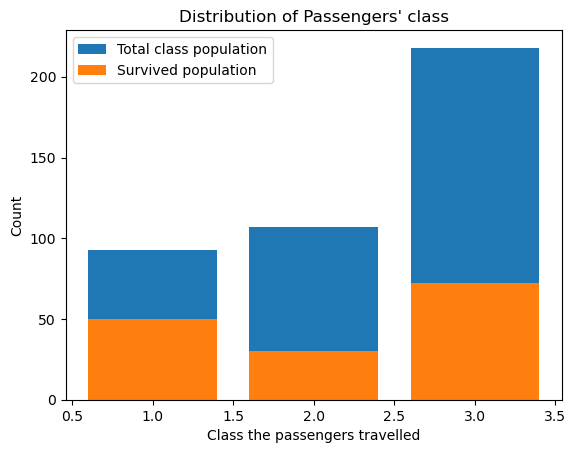

In [46]:
plot.bar(PclassBarPlotX, PclassTotalBarPlotY)
plot.bar(PclassBarPlotX, PclassSurvivedBarPlotY)
plot.xlabel('Class the passengers travelled')
plot.ylabel('Count')
plot.legend(['Total class population', 'Survived population'])
plot.title("Distribution of Passengers' class")

In [18]:
plot.close()

In [75]:
length = len(PclassBarPlotX)
PclassSurvivedPercentage = dict()
for i in range(length):
    classpop = PclassTotalBarPlotY[i]
    survivedpop = PclassSurvivedBarPlotY[i]
    survivedpercentage = (survivedpop/classpop)*100
    PclassSurvivedPercentage[PclassBarPlotX[i]] = survivedpercentage
PClassSurvivedPercentageDF = pd.DataFrame(list(PclassSurvivedPercentage.items()), columns=['Pclass', 'SurvivedPercentage'])

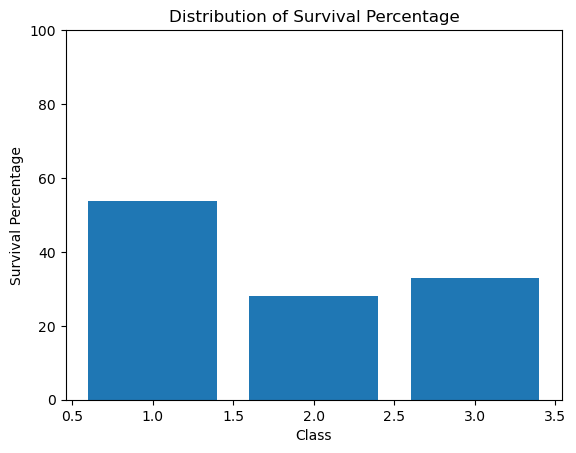

In [76]:
plot.bar(PclassSurvivedPercentage.keys(), PclassSurvivedPercentage.values())
plot.ylim(0, 100)
plot.title('Distribution of Survival Percentage')
plot.xlabel('Class')
plot.ylabel('Survival Percentage')
plot.show()

In [70]:
tempDf = df['Sex'].value_counts()
SexBarPlotX = df['Sex'].unique()
SexTotalBarPlotY = tempDf.tolist()
SexSurvivedBarPlotY = [len(df[(df['Sex']==SexBarPlotX[i]) & (df['Survived']==1)]) for i in range(len(SexBarPlotX))]

Text(0, 0.5, 'Count')

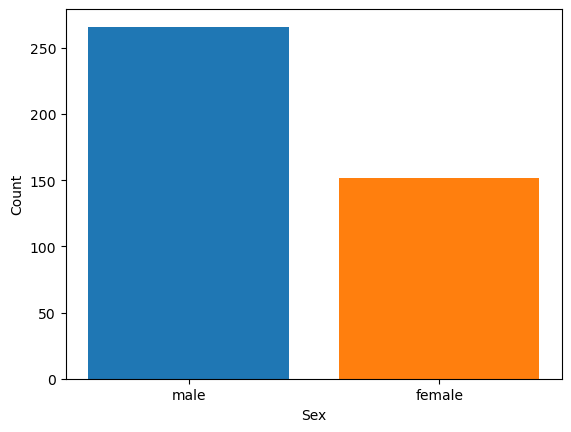

In [71]:
plot.bar(SexBarPlotX, SexTotalBarPlotY)
plot.bar(SexBarPlotX, SexSurvivedBarPlotY)
plot.xlabel("Sex")
plot.ylabel("Count")

In [74]:
df[(df['Sex']=='female')&(df['Survived']==1)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S
6,898,1,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,Q
8,900,1,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,C
12,904,1,1,"Snyder, Mrs. John Pillsbury (Nelle Stevenson)",female,23.0,1,0,21228,82.2667,S
...,...,...,...,...,...,...,...,...,...,...,...
409,1301,1,3,"Peacock, Miss. Treasteall",female,3.0,1,1,SOTON/O.Q. 3101315,13.7750,S
410,1302,1,3,"Naughton, Miss. Hannah",female,20.0,0,0,365237,7.7500,Q
411,1303,1,1,"Minahan, Mrs. William Edward (Lillian E Thorpe)",female,37.0,1,0,19928,90.0000,Q
412,1304,1,3,"Henriksson, Miss. Jenny Lovisa",female,28.0,0,0,347086,7.7750,S


In [80]:
length = len(SexBarPlotX)
SexSurvivedPercentage = dict()
for i in range(length):
    sexpop = SexTotalBarPlotY[i]
    survivedpop = SexSurvivedBarPlotY[i]
    survivedpercentage = (survivedpop/sexpop)*100
    SexSurvivedPercentage[SexBarPlotX[i]] = survivedpercentage
SexSurvivedPercentageDF = pd.DataFrame(list(SexSurvivedPercentage.items()), columns=['Sex', 'SurvivedPercentage'])
SexSurvivedPercentageDF

,Sex,SurvivedPercentage
0,male,0.0
1,female,100.0
